# Comparison with 100 descriptors

In [11]:
import pandas as pd

# 721 positive data points
df_pos = pd.read_csv("../data/examples_DBAASP/descriptors_positive_staphylococcus.csv")
# 246 negative data points
df_neg = pd.read_csv("../data/examples_random_peptides_SwissProt/descriptors_negative.csv")

# merge into one dataframe
df = pd.concat([df_pos, df_neg])

In [12]:
# normalizing the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df)
df_feat = pd.DataFrame(scaled_features, columns=df.columns)

# variance treshold - remove features with zero variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit(df_feat)
df_feat = df_feat[df_feat.columns[selector.get_support(indices=True)]]
print("-----Variance treshold-----")
print(f"Features dropped: {df.columns[~selector.get_support()]}")
print(f"New shape: {df_feat.shape}\n")


# trash randomly one of the features with correlation > 0.85
import numpy as np
corr_matrix = df_feat.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
df_feat = df_feat.drop(columns=to_drop)
print("-----Correlation filter-----")
print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}\n")


# trash all features with "BLOSUM" in the name
to_drop = [col for col in df_feat.columns if "BLOSUM" in col]
df_feat = df_feat.drop(columns=to_drop)
print("-----Filter by name-----")
print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}\n")

-----Variance treshold-----
Features dropped: Index([], dtype='object')
New shape: (967, 102)

-----Correlation filter-----
Features dropped: ['F2', 'F3', 'KF1', 'KF2', 'KF4', 'MSWHIM1', 'E1', 'E2', 'E5', 'PD1', 'PD2', 'PRIN1', 'PRIN2', 'ProtFP1', 'ProtFP2', 'SV2', 'ST1', 'ST6', 'SVGER1', 'SVGER7', 'SVGER10', 'T1', 'T4', 'T5', 'VHSE1', 'VHSE2', 'VHSE3', 'VHSE5', 'VSTPV1', 'VSTPV2', 'VSTPV3', 'Z1', 'Z2', 'Z4']
New shape: (967, 68)

-----Filter by name-----
Features dropped: ['BLOSUM1', 'BLOSUM2', 'BLOSUM3', 'BLOSUM4', 'BLOSUM5', 'BLOSUM6', 'BLOSUM7', 'BLOSUM8', 'BLOSUM9', 'BLOSUM10']
New shape: (967, 58)


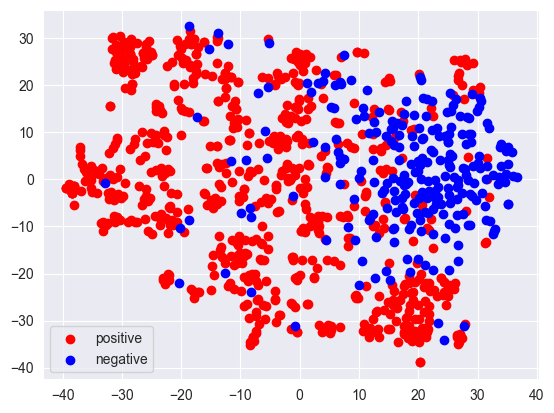

In [13]:
# TSNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(df_feat)
# distinguish from index 721
plt.scatter(X_embedded[:721, 0], X_embedded[:721, 1], c='r', label='positive')
plt.scatter(X_embedded[721:, 0], X_embedded[721:, 1], c='b', label='negative')
plt.legend()
plt.show()

# Comparison with 5 descriptors (pcp)

In [14]:
import pandas as pd

# 721 positive data points
df_pos = pd.read_csv("../data/examples_DBAASP/pcp_descriptors_positive_staphylococcus.csv")
# 246 negative data points
df_neg = pd.read_csv("../data/examples_random_peptides_SwissProt/pcp_descriptors_negative.csv")

# merge into one dataframe
df = pd.concat([df_pos, df_neg])

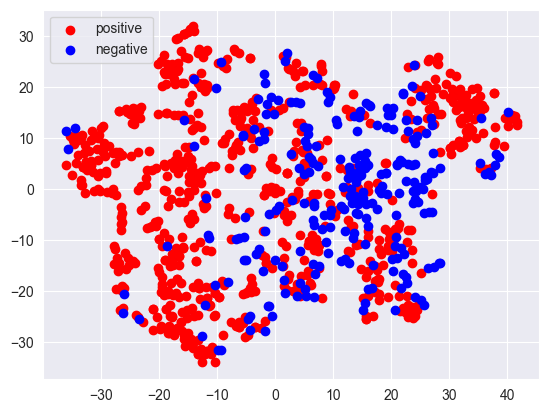

In [16]:
# TSNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(df_feat)
# distinguish from index 721
plt.scatter(X_embedded[:721, 0], X_embedded[:721, 1], c='r', label='positive')
plt.scatter(X_embedded[721:, 0], X_embedded[721:, 1], c='b', label='negative')
plt.legend()
plt.show()